## **Praktikum Pengolahan Sinyal Digital**



---


* Nama: Raka Muhammad Al Hafidz
* NIM: 241344087
* Kelas: 2C-TNK


# Modul 9 - Transformasi Fourier

## Pendahuluan.
Salah satu tujuan kuliah pengolahan sinyal digital adalah menganalisa sinyal yang rumit, misalnya menentukan sinyal-sinyal dasar yang dominan pada suatu sinyal yang mengandung derau (noise). Sinyal dasar yang umumnya dipakai adalah sinyal sinusoida (dengan parameter amplitudo, frekuensi dan fasanya). Ada 2 perangkat matematika dasar yang dapat digunakan untuk menganalisa dan mengolah sinyal, yang sama-sama menggunakan prinsip superposisi. Kedua perangkat itu adalah konvolusi dan transformasi Fourier. Teknik konvolusi telah kita pelajari pada praktikum-praktikum terdahulu. Dimulai dari percobaan ini, kita akan mencoba memahami teknik analisa sinyal dengan menggunakan Transformasi Fourier.


Fourier ada yang analog, tapi yg kali ini diskrit, berarti tidak analog melainkan digital.

## Bagian Pendahuluan

Buat 3 sinyal dasar yang memiliki frekuensi 3 Hz, 6 Hz dan 9 Hz, set frekuensi sampling 1000 Hz dan durasi selama 2 detik. Lalu buat sinyal gabungan ketiga sinyal tersebut. Plot keempat sinyal dalam jendela plot yang sama. Jangan lupa import library yang diperlukan.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# import pandas as pd
# from scipy.signal import find_peaks
# from scipy.io import wavfile


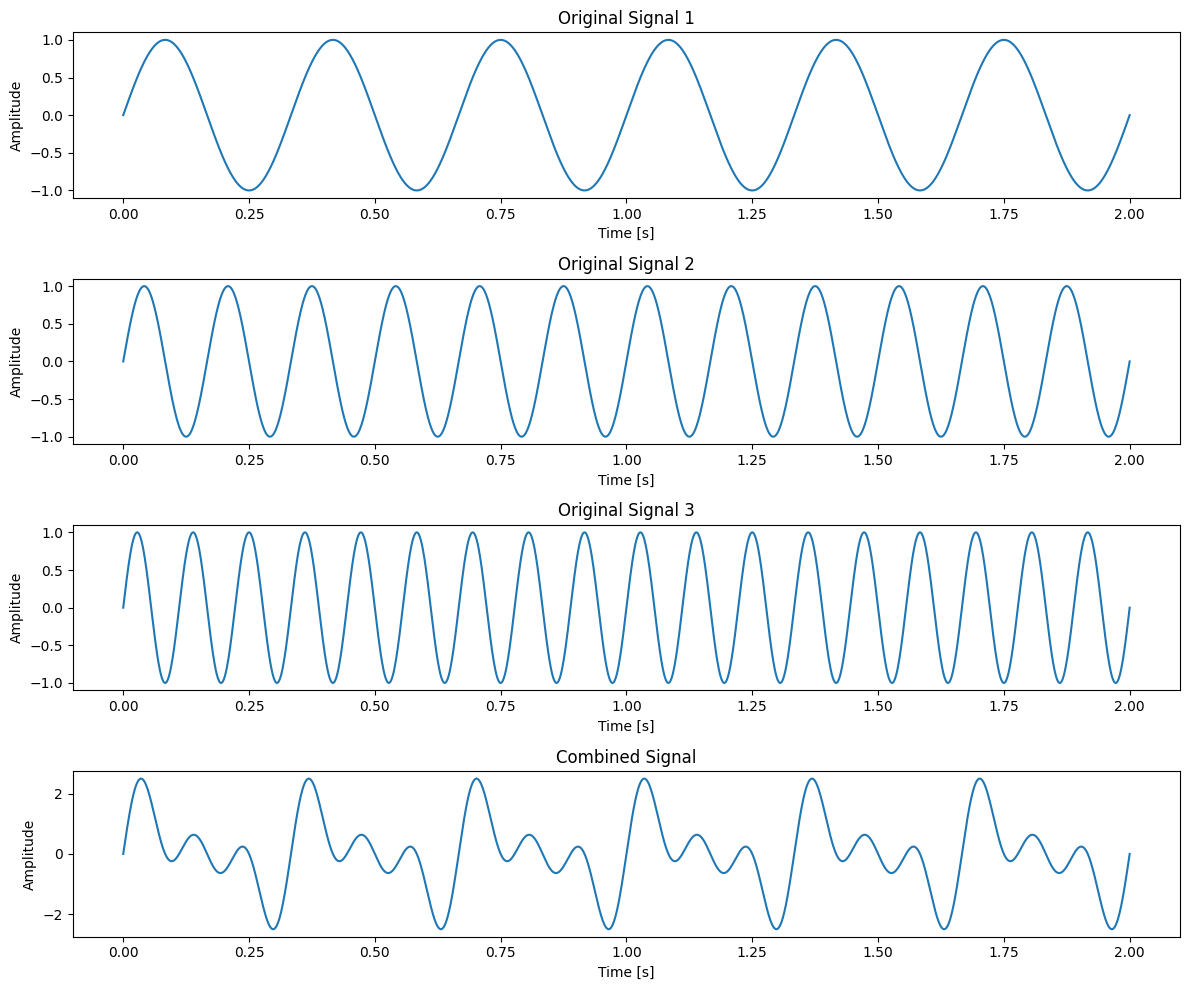

In [30]:
fs = 1000
dur = 2
f1 = 3
f2 = 6
f3 = 9
A = 1

t = np.linspace(0, dur, int(fs * dur))
signal1 = A * np.sin(2 * np.pi * f1 * t)
signal2 = A * np.sin(2 * np.pi * f2 * t)
signal3 = A * np.sin(2 * np.pi * f3 * t)
signal = signal1 + signal2 + signal3

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(t, signal1)
axes[0].set_title("Original Signal 1")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")

axes[1].plot(t, signal2)
axes[1].set_title("Original Signal 2")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")

axes[2].plot(t, signal3)
axes[2].set_title("Original Signal 3")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Amplitude")

axes[3].plot(t, signal)
axes[3].set_title("Combined Signal")
axes[3].set_xlabel("Time [s]")
axes[3].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()


## Bagian Percobaan

### 1. Gunakan fungsi ```np.fft.fft()``` terhadap masing-masing sinyal dan juga sinyal gabungan. Plot masing-masing hasil fft menggunakan ```np.fft.fftfreq()``` sebagai sumbu x dan hasil fft sebagai sumbu y.
### Untuk melakukan FFT
- hitung jumlah n data
- untuk menggunakan ```np.fft.fftfreq()``` inputnya ialah jumlah n data
- untuk plotting hasil fft, hasil fft harus dihitung magnitudanya dengan menggunakan ```np.abs()```
- setelah itu dinormalisasikan

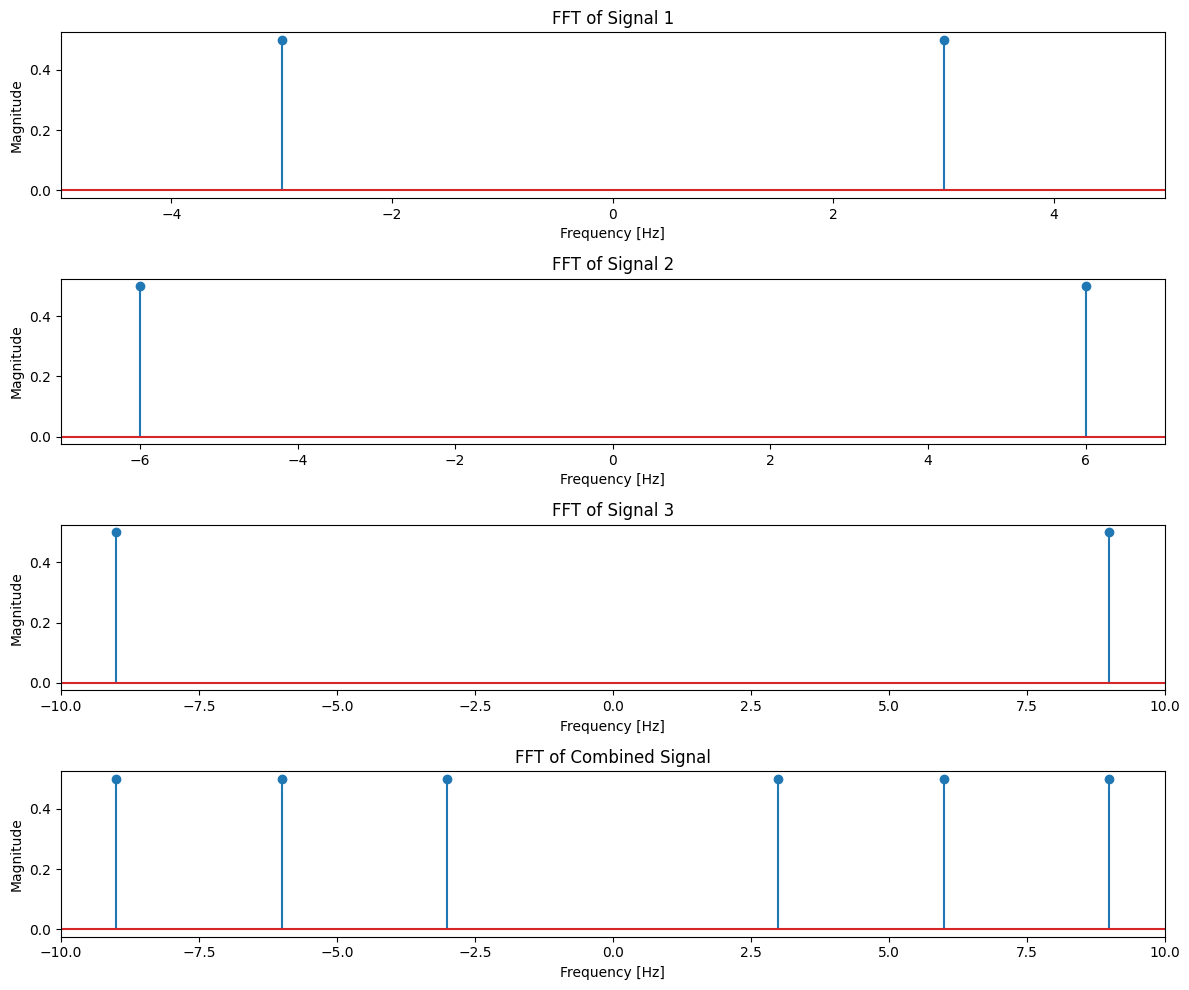

In [ ]:

n_total = len(signal)

fft1 = np.fft.fft(signal1)
fft2 = np.fft.fft(signal2)
fft3 = np.fft.fft(signal3)
fft4 = np.fft.fft(signal)

x = np.fft.fftfreq(n_total, 1/fs)

fft1 = fft1 / n_total
fft2 = fft2 / n_total
fft3 = fft3 / n_total
fft4 = fft4 / n_total

#filter where fft > 0.2

fft1[np.abs(fft1) < 0.2] = None
fft2[np.abs(fft2) < 0.2] = None
fft3[np.abs(fft3) < 0.2] = None
fft4[np.abs(fft4) < 0.2] = None

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].stem(x, np.abs(fft1))
axes[0].set_xlim(-5, 5)
axes[0].set_title("FFT of Signal 1")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Magnitude")

axes[1].stem(x, np.abs(fft2))
axes[1].set_xlim(-7, 7)
axes[1].set_title("FFT of Signal 2")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude")

axes[2].stem(x, np.abs(fft3))
axes[2].set_xlim(-10, 10)
axes[2].set_title("FFT of Signal 3")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("Magnitude")

axes[3].stem(x, np.abs(fft4))
axes[3].set_xlim(-10, 10)
axes[3].set_title("FFT of Combined Signal")
axes[3].set_xlabel("Frequency [Hz]")
axes[3].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()



a. Dari pengamatan hasil, menurut Anda untuk apa penggunaan fungsi ```np.fft.fft()```, dan ```np.fft.fftfreq()```

> Penggunaan fungsi `np.fft.fft()` adalah untuk mengubah sinyal yang tadinya bersifat kontinu menjadi diskrit. `np.fft.fftfreq()` adalah fungsi yang digunakan untuk mengkonversi sumbu waktu ke frekuensi. Ibarat `np.fft.fft()` adalah `np.sin()`-nya, sedangkan `np.fft.fftfreq()` adalah `t` nya

b. Lalu, dari hasil plot nilai apa yang dihasilkan oleh fungsi ```np.fft.fft()```, dan ```np.fft.fftfreq()```

> Hasil plot nilai yang dihasilkan oleh kedua fungsi tersebut adalah ploting nilai transformasi fourier diskrit

c. Menurut Anda mengapa ada hasil negatif dari plot fft

> Ada hasil negatif dikarenakan adalah sifat dari `sin()` itu sendiri yang mempunyai sisi positif dan negatif. menmnurut rumus euler:
$$
sin(2πft)= \frac{2je^{j2πft}−e^{-j2πft}​}{2j}
$$

> Artinya, 1 sinyal sinus = 2 komponen frekuensi: satu di +f dan 1 lagi di -f.

> Frekuensi adalah sifat matematika FFT. Dalam praktiknya, cukup lihat sisi positif saja karena sisi negatif hanya mirror dari sisi positif.

> Untuk membuang sisi negatifnya, tinggal gunakan:
`fft1 = np.fft.rfft(signal1, r = real)`

### 2. Buat lagi sinyal gabungan yang merupakan 3 sinyal sinusoidal yang memiliki frekuensi 10, 30, dan 60 Hz. Buat tiga variasi dari sinyal sinusoidal tersebut dengan mengubah frekuensi samplingnya dari 300Hz, 150Hz, 120Hz, dan 90Hz. (tidak perlu di plot)

In [32]:

fs1  = 300
fs2 = 150
fs3 = 120
fs4 = 90

f1,f2,f3 = 10, 30, 60
dur = 2

t1 = np.linspace(0, dur, int(fs1 * dur))
t2 = np.linspace(0, dur, int(fs2 * dur))
t3 = np.linspace(0, dur, int(fs3 * dur))
t4 = np.linspace(0, dur, int(fs4 * dur))

signal_comb1 = np.sin(2 * np.pi * f1 * t1) + np.sin(2 * np.pi * f2 * t1) + np.sin(2 * np.pi * f3 * t1)
signal_comb2 = np.sin(2 * np.pi * f1 * t2) + np.sin(2 * np.pi * f2 * t2) + np.sin(2 * np.pi * f3 * t2)
signal_comb3 = np.sin(2 * np.pi * f1 * t3) + np.sin(2 * np.pi * f2 * t3) + np.sin(2 * np.pi * f3 * t3)
signal_comb4 = np.sin(2 * np.pi * f1 * t4) + np.sin(2 * np.pi * f2 * t4) + np.sin(2 * np.pi * f3 * t4)


a. Lakukan Transfomasi Fourier untuk keempat sinyal tersebut dan plot hasilnya side by side.

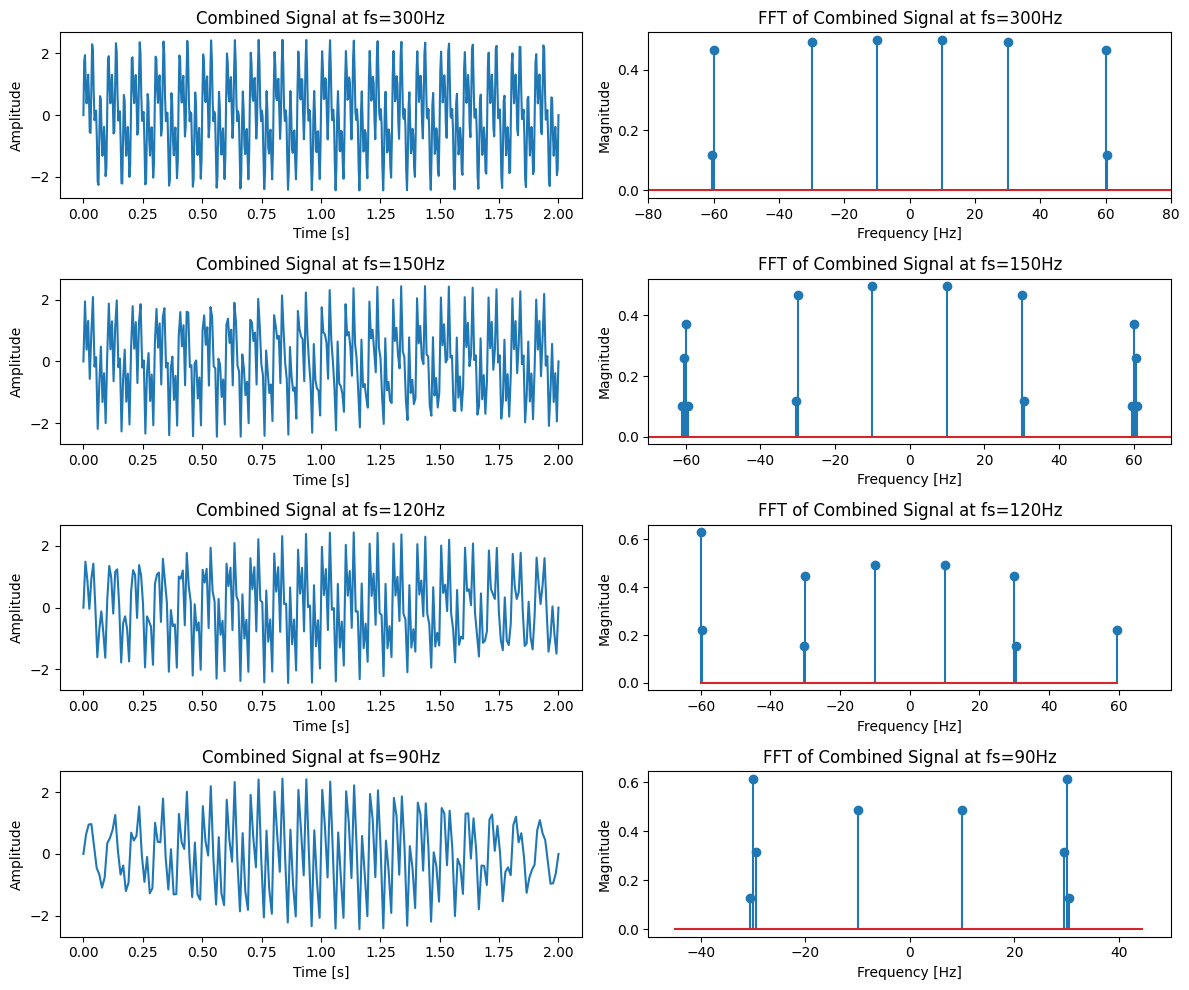

In [ ]:
fft_signal_comb1 = np.fft.fft(signal_comb1)
fft_signal_comb2 = np.fft.fft(signal_comb2)
fft_signal_comb3 = np.fft.fft(signal_comb3)
fft_signal_comb4 = np.fft.fft(signal_comb4)

x1 = np.fft.fftfreq(len(signal_comb1), 1/fs1)
x2 = np.fft.fftfreq(len(signal_comb2), 1/fs2)
x3 = np.fft.fftfreq(len(signal_comb3), 1/fs3)
x4 = np.fft.fftfreq(len(signal_comb4), 1/fs4)

#Normalize the FFT results so the magnitude is between 0 and 1
fft_signal_comb1 = fft_signal_comb1 / len(signal_comb1)
fft_signal_comb2 = fft_signal_comb2 / len(signal_comb2)
fft_signal_comb3 = fft_signal_comb3 / len(signal_comb3)
fft_signal_comb4 = fft_signal_comb4 / len(signal_comb4)

fft_signal_comb1[np.abs(fft_signal_comb1) < 0.1] = None
fft_signal_comb2[np.abs(fft_signal_comb2) < 0.1] = None
fft_signal_comb3[np.abs(fft_signal_comb3) < 0.1] = None
fft_signal_comb4[np.abs(fft_signal_comb4) < 0.1] = None

#Plot left side signal and right side fft

fig, axes = plt.subplots(4, 2, figsize=(12, 10))

axes[0, 0].plot(t1, signal_comb1)
axes[0, 0].set_title("Combined Signal at fs=300Hz")
axes[0, 0].set_xlabel("Time [s]")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].stem(x1, np.abs(fft_signal_comb1))
axes[0, 1].set_xlim(-80, 80)
axes[0, 1].set_title("FFT of Combined Signal at fs=300Hz")
axes[0, 1].set_xlabel("Frequency [Hz]")
axes[0, 1].set_ylabel("Magnitude")

axes[1, 0].plot(t2, signal_comb2)
axes[1, 0].set_title("Combined Signal at fs=150Hz")
axes[1, 0].set_xlabel("Time [s]")
axes[1, 0].set_ylabel("Amplitude")

axes[1, 1].stem(x2, np.abs(fft_signal_comb2))
axes[1, 1].set_xlim(-70, 70)
axes[1, 1].set_title("FFT of Combined Signal at fs=150Hz")
axes[1, 1].set_xlabel("Frequency [Hz]")
axes[1, 1].set_ylabel("Magnitude")

axes[2, 0].plot(t3, signal_comb3)
axes[2, 0].set_title("Combined Signal at fs=120Hz")
axes[2, 0].set_xlabel("Time [s]")
axes[2, 0].set_ylabel("Amplitude")

axes[2, 1].stem(x3, np.abs(fft_signal_comb3))
axes[2, 1].set_xlim(-75, 75)
axes[2, 1].set_title("FFT of Combined Signal at fs=120Hz")
axes[2, 1].set_xlabel("Frequency [Hz]")
axes[2, 1].set_ylabel("Magnitude")

axes[3, 0].plot(t4, signal_comb4)
axes[3, 0].set_title("Combined Signal at fs=90Hz")
axes[3, 0].set_xlabel("Time [s]")
axes[3, 0].set_ylabel("Amplitude")

axes[3, 1].stem(x4, np.abs(fft_signal_comb4))
axes[3, 1].set_xlim(-50, 50)
axes[3, 1].set_title("FFT of Combined Signal at fs=90Hz")
axes[3, 1].set_xlabel("Frequency [Hz]")
axes[3, 1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

b. Dari hasil plot, apakah ada anomali dari hasilnya. Jika ya, deskripsikan hal tersebut, dan jelaskan kira-kira mengapa hal tersebut dapat terjadi.

> Yang dimaksud anomali disini adalah spike yang lonjakannya tidak pada frekuensi yang sebenarnya (ditetapkan)
> Di atas, ditetapkan bahwa f = 10, 30, dan 60.

> Anomali ditemukan pada fs = 90Hz - 150Hz.
> Pada 90Hz terlihat bahwa ada suatu titik kecil yang diplotingkan sebelum dan sesudah batas, yakni 30Hz.
> Pada 120Hz, ada lonjakan yang tinggi sekali pada -60Hz. Hal tersebut tidak simetris dengan yang ada pada 60Hz.
> Pada 150Hz, kasusnya sama dengan yang ada pada 90Hz, ada sebuah lonjakan di titik kecil sebelum dan sesudah 60Hz.

> Nyquist berkata bawhwa frekuensi sampling harusnya 2x dari frekuensi tertinggi sinyal. Kalau tidak, frekuensi tinggi "terlipat balik" ke posisi palsu:
$$
f_{alias​} = f_{s​} − f_{asli​}
$$

> Contoh di fs=90Hz, frekuensi 60Hz mengalami aliasing:
$$f_{\text{alias}} = 90 - 60 = 30\ \text{Hz}$$


>Makanya muncul spike di $~±30 Hz$ padahal frekuensi aslinya 60Hz

### 3. Buat gabungan sinyal harmonik dengan menumpukkan sejumlah sinyal sinusoidal yang memiliki
 - amplitudo $$ \frac{1} {2 k-1} $$
 - frekuensi $$ 2k-1 $$
 di mana $k$ menunjukkan sinyal ke-1, ke-2 ... ke-k

 Buat k agar hasil sinyal mendekati sinyal kotak

Mengganti nilai amplitudo dan mengganti nilai frekuensi, jadi frekuensi nya tadi ditumpuk (ditambahin)

Contoh dibawah ketika k=10

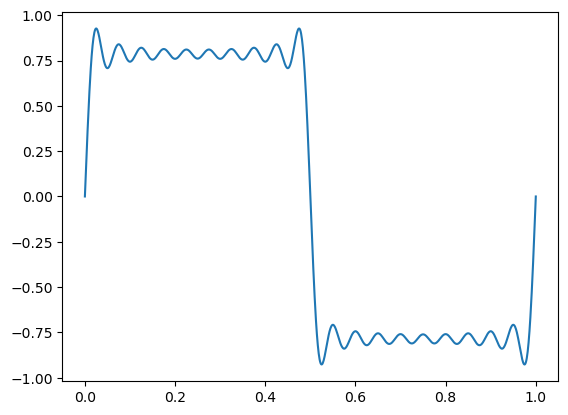

Frequency: 199 Hz, Amplitude: 0.005025125628140704


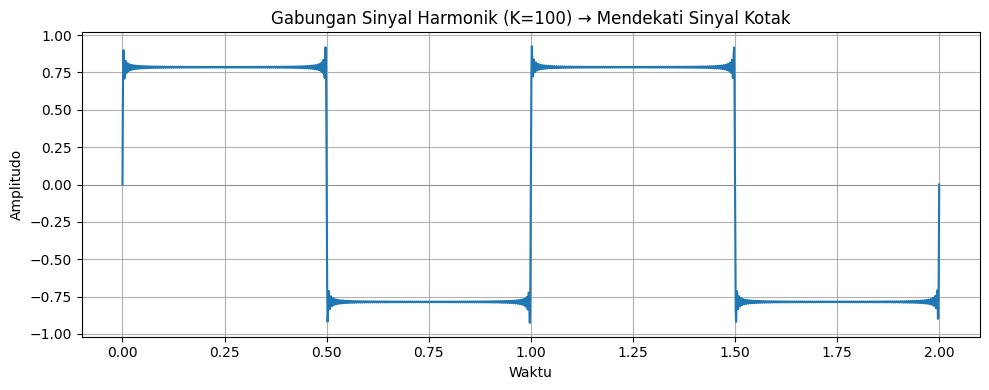

In [40]:
fs = 1000
kCount = 100
dur = 2
A = 0

s = np.zeros(int(fs * dur))
t = np.linspace(0, dur, int(fs * dur))

for k in range(1, kCount + 1):
   A = 1/(2 * k - 1)
   f = 2 * k - 1
   s += A * np.sin(2 * np.pi * f * t)

print(f"Frequency: {f} Hz, Amplitude: {A}")
plt.figure(figsize=(10, 4))
plt.plot(t, s)
plt.title(f'Gabungan Sinyal Harmonik (K={k}) → Mendekati Sinyal Kotak')
plt.xlabel('Waktu')
plt.ylabel('Amplitudo')
plt.axhline(0, color='gray', linewidth=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()

> Percobaan ini membuktikan bahwa sinyal kotak bisa dibentuk dari penjumlahan banyak gelombang sinus, sesuai rumus:
$$
s(t)=k= \sum_{k=1}^{K} \frac{1}{2k-1} ​sin(2π(2k−1)t)
$$

>Semakin banyak K, gelombang kecil di bagian datar makin halus dan tepi kotak makin tegak. Tapi tidak akan pernah sempurna 100% karena butuh K = ∞ untuk kotak sempurna.
>Di K=100, hasilnya sudah sangat mirip kotak — bagian atas flat di ±0.75 dan bawah di ±-0.75



3.a Lakukan Transfomasi Fourier terhadap sinyal tersebut dan plot hasilnya

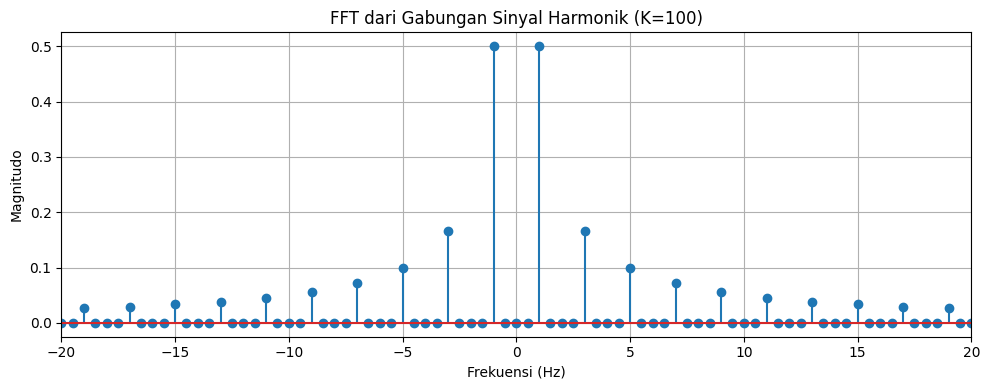

In [41]:
s_signal_count = len(s)

fft_signal_s = np.fft.fft(s)
x = np.fft.fftfreq(s_signal_count, 1/fs)

fft_signal_s = fft_signal_s / s_signal_count

# fft_signal_s[np.abs(fft_signal_s) < 0.1] = None

plt.figure(figsize=(10, 4))
plt.stem(x, np.abs(fft_signal_s))
plt.xlim(-20, 20)
plt.title(f'FFT dari Gabungan Sinyal Harmonik (K={k})')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitudo')
plt.grid(True)
plt.tight_layout()
plt.show()


> Plot menampilkan frekuensi dari −20 sampai +20 Hz saja, hal itu terjadi karena dibatasi.
> Padahal sinyal komponen sampai ke frekuensi 100Hz

> Spike muncul hanya di ±1,±3,±5,±7... Hz, tidak pernah di frekuensi genap. Ini karena rumus 2k−1 selalu menghasilkan bilangan ganjil
> Sinyal kotak punya simetri setengah gelombang (bagian atas dan bawahnya simetris). Sifat ini secara matematis menghilangkan semua harmonik genap otomatis.

> Garisnya makin pendek ke samping disebabkan oleh rumus A itu sendiri



---


© Prof. Hertog Nugroho, Teguh Ginanjar S.T., M.T, Muhammad Yusuf Fadhlan, SST., M.Sc & Nila Novitasari SST., MSc.

Politeknik Negeri Bandung (2025)